In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!ls /content/drive/MyDrive

 cardd	'Colab Notebooks'


In [ ]:
!ls /content/drive/MyDrive/cardd

image_info.xlsx  test  test.json  train  train.json  val  val.json


In [ ]:
import os
base_path = "/content/drive/MyDrive/cardd"
train_path = "/content/drive/MyDrive/cardd/train"
test_path = "/content/drive/MyDrive/cardd/test"
val_path = "/content/drive/MyDrive/cardd/val"

In [ ]:
folders = [f for f in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, f))]
print("Folders in dataset:", folders)

Folders in dataset: ['test', 'train', 'val']


In [ ]:
import os

print("Train Images:", len(os.listdir("/content/drive/MyDrive/cardd/train")))
print("Val Images:", len(os.listdir("/content/drive/MyDrive/cardd/val")))
print("Test Images:", len(os.listdir("/content/drive/MyDrive/cardd/test")))

Train Images: 3116
Val Images: 860
Test Images: 424


In [ ]:
import json
with open("/content/drive/MyDrive/cardd/train.json", "r") as f:
    data = json.load(f)

categories = data["categories"]
print("Number of damage categories:", len(categories))
print("Damage Categories:\n")

for cat in categories:
    print(f"ID: {cat['id']} | Name: {cat['name']}")


Number of damage categories: 6
Damage Categories:

ID: 1 | Name: dent
ID: 2 | Name: scratch
ID: 3 | Name: crack
ID: 4 | Name: glass shatter
ID: 5 | Name: lamp broken
ID: 6 | Name: tire flat


In [ ]:
from collections import Counter

category_count = Counter()

for ann in data["annotations"]:
    category_count[ann["category_id"]] += 1

print("Annotation count per category:")
for cat in categories:
    print(f"{cat['name']}: {category_count[cat['id']]}")


Annotation count per category:
dent: 1806
scratch: 2560
crack: 651
glass shatter: 475
lamp broken: 494
tire flat: 225


In [ ]:
split = "train"
folder = os.path.join(base_path, split)
images = os.listdir(folder)

for img_name in images[:5]:  # check first 5
    img_path = os.path.join(folder, img_name)
    img = cv2.imread(img_path)
    h, w = img.shape[:2]
    print(f"{img_name}: width={w}, height={h}")

003002.jpg: width=1000, height=667
003003.jpg: width=1000, height=750
003004.jpg: width=1000, height=667
003005.jpg: width=1000, height=667
003006.jpg: width=1000, height=667


In [ ]:
import json

annotation_file = os.path.join(base_path, "train.json")
with open(annotation_file) as f:
    data = json.load(f)

image_id_to_ann_count = {}
for ann in data['annotations']:
    image_id_to_ann_count[ann['image_id']] = image_id_to_ann_count.get(ann['image_id'], 0) + 1

# print first 5 images
for img in data['images'][:5]:
    img_id = img['id']
    print(f"Image {img['file_name']} has {image_id_to_ann_count.get(img_id, 0)} annotation(s)")

Image 000001.jpg has 2 annotation(s)
Image 000002.jpg has 1 annotation(s)
Image 000003.jpg has 1 annotation(s)
Image 000004.jpg has 1 annotation(s)
Image 000005.jpg has 1 annotation(s)



Showing from TRAIN set

loading annotations into memory...
Done (t=0.11s)
creating index...
index created!


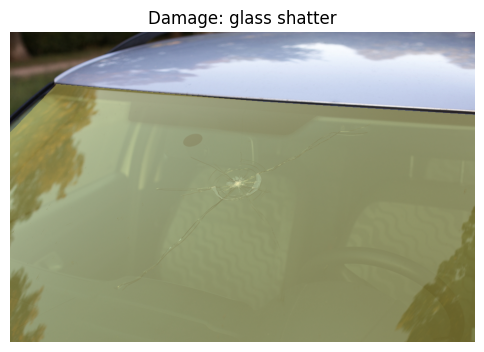

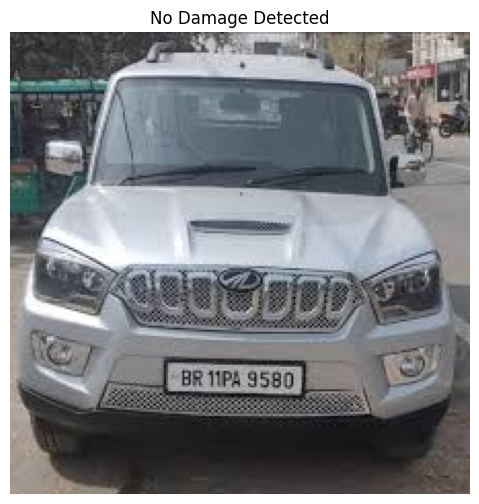


Showing from VAL set

loading annotations into memory...
Done (t=0.05s)
creating index...
index created!


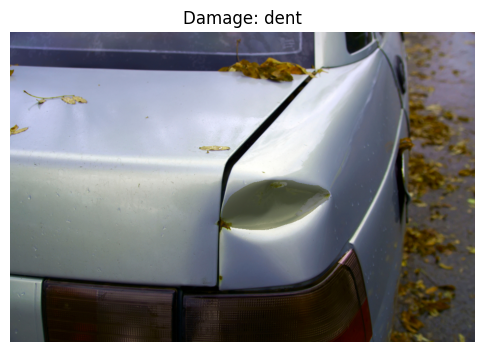

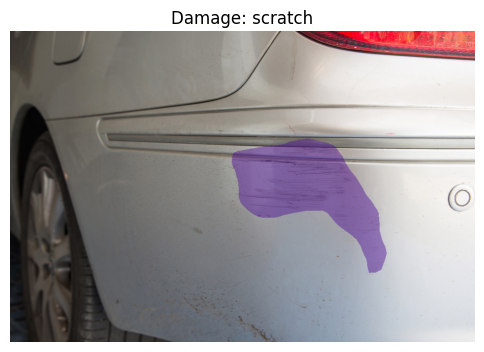


Showing from TEST set

loading annotations into memory...
Done (t=0.03s)
creating index...
index created!


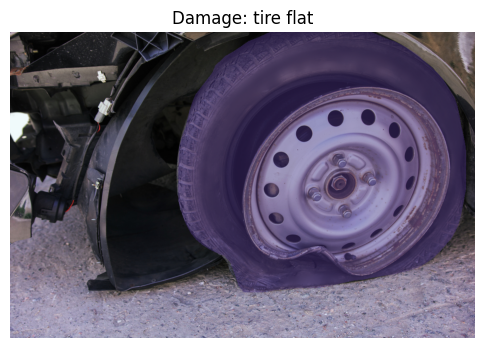

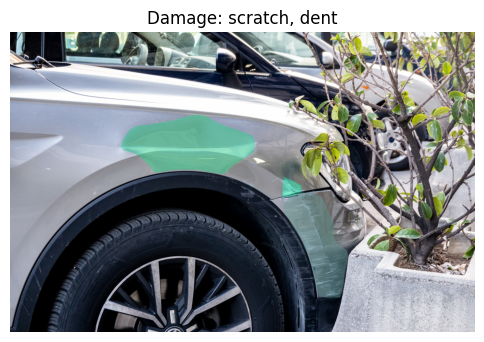

In [ ]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pycocotools.coco import COCO


# Function to visualize random images
def show_random_images(split_name, num_images=2):

    print(f"\nShowing from {split_name.upper()} set\n")

    images_path = os.path.join(base_path, split_name)
    annotation_path = os.path.join(base_path, f"{split_name}.json")

    coco = COCO(annotation_path)
    img_ids = coco.getImgIds()

    # Select random images
    num_images = min(num_images, len(img_ids))
    random_ids = random.sample(img_ids, num_images)

    for img_id in random_ids:

        img_info = coco.loadImgs(img_id)[0]
        img_path = os.path.join(images_path, img_info['file_name'])

        image = cv2.imread(img_path)
        if image is None:
            print(f"Could not read image: {img_path}")
            continue

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        ann_ids = coco.getAnnIds(imgIds=img_id)
        anns = coco.loadAnns(ann_ids)

        category_names = []

        for ann in anns:
            mask = coco.annToMask(ann)

            # Get category name
            cat_id = ann['category_id']
            cat_name = coco.loadCats(cat_id)[0]['name']
            category_names.append(cat_name)

            # Medium color mask (alpha = 0.45)
            color = np.random.randint(0, 255, (3,), dtype=np.uint8)
            alpha = 0.45
            image[mask == 1] = image[mask == 1] * (1 - alpha) + color * alpha

        # Handle images with no damage
        if len(category_names) == 0:
            title_text = "No Damage Detected"
        else:
            title_text = "Damage: " + ", ".join(set(category_names))

        plt.figure(figsize=(6,6))
        plt.imshow(image.astype(np.uint8))
        plt.axis("off")
        plt.title(title_text)
        plt.show()


# Show images from all splits
show_random_images("train", 2)
show_random_images("val", 2)
show_random_images("test", 2)

In [ ]:
import json
import os

annotation_file_path = os.path.join(base_path, "train.json")
with open(annotation_file_path) as f:
    data = json.load(f)

print(list(data.items())[0])
print(list(data.items())[1])
print(list(data.items())[2])
print(list(data.items())[3])
print(list(data.items())[4])


('licenses', [{'name': 'CarDD', 'id': 0, 'url': 'https://cardd-ustc.github.io/'}])
('info', {'contributor': 'Xinkuang Wang, Wenjing Li, Zhongcheng Wu', 'date_created': '2022.05.01', 'description': 'CarDD for car damage detection in COCO Format.', 'url': 'https://cardd-ustc.github.io/', 'version': 'v1.0'})
('categories', [{'id': 1, 'name': 'dent', 'supercategory': 'car damages'}, {'id': 2, 'name': 'scratch', 'supercategory': 'car damages'}, {'id': 3, 'name': 'crack', 'supercategory': 'car damages'}, {'id': 4, 'name': 'glass shatter', 'supercategory': 'car damages'}, {'id': 5, 'name': 'lamp broken', 'supercategory': 'car damages'}, {'id': 6, 'name': 'tire flat', 'supercategory': 'car damages'}])
('images', [{'id': 1, 'width': 1000, 'height': 750, 'file_name': '000001.jpg', 'license': 0}, {'id': 2, 'width': 1000, 'height': 667, 'file_name': '000002.jpg', 'license': 0}, {'id': 3, 'width': 1000, 'height': 667, 'file_name': '000003.jpg', 'license': 0}, {'id': 4, 'width': 1000, 'height': 667,

In [ ]:
# For example, images
images = data['images']
annotations = data['annotations']
categories = data['categories']

print("First 5 images:")
for img in images[:5]:
    print(img)

print("\nFirst 5 annotations:")
for ann in annotations[:5]:
    print(ann)

print("\nCategories:")
for cat in categories:
    print(cat)

First 5 images:
{'id': 1, 'width': 1000, 'height': 750, 'file_name': '000001.jpg', 'license': 0}
{'id': 2, 'width': 1000, 'height': 667, 'file_name': '000002.jpg', 'license': 0}
{'id': 3, 'width': 1000, 'height': 667, 'file_name': '000003.jpg', 'license': 0}
{'id': 4, 'width': 1000, 'height': 667, 'file_name': '000004.jpg', 'license': 0}
{'id': 5, 'width': 1000, 'height': 667, 'file_name': '000005.jpg', 'license': 0}

First 5 annotations:
{'id': 1, 'image_id': 1, 'category_id': 2, 'segmentation': [[233.35, 46.65, 217.25, 58.24, 210.82, 65.97, 204.38, 78.2, 197.3, 93.0, 192.15, 104.59, 187.0, 112.96, 180.56, 123.91, 174.12, 135.49, 169.61, 144.51, 167.04, 154.16, 167.04, 165.11, 175.41, 170.9, 185.71, 171.55, 196.01, 167.68, 205.02, 161.24, 214.03, 154.81, 224.33, 148.37, 233.99, 141.93, 244.29, 134.21, 256.52, 128.41, 267.47, 125.19, 277.77, 122.62, 288.71, 119.4, 298.37, 116.82, 310.6, 113.61, 322.83, 109.1, 333.13, 105.88, 344.08, 103.95, 355.02, 101.37, 366.61, 97.51, 369.83, 87.21,

First image info:
{'id': 1, 'width': 1000, 'height': 750, 'file_name': '000001.jpg', 'license': 0}

Annotations for first image:
Annotation ID: 1, Category: scratch, BBox: [167.04, 40.21, 202.79, 131.34], Area: 13584.0
Annotation ID: 2, Category: tire flat, BBox: [160.66, 112.45, 684.19, 551.02], Area: 298742.0


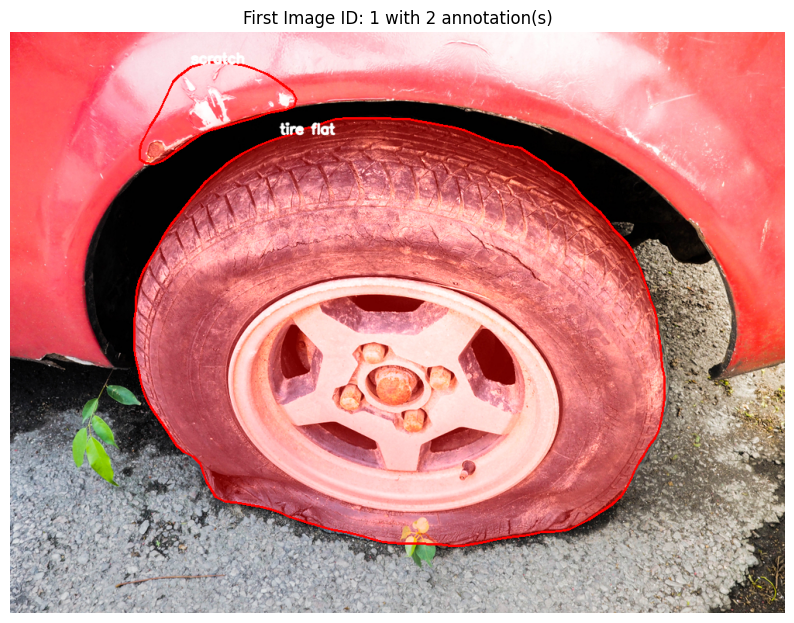

In [ ]:
annotation_file_path = os.path.join(base_path, "train.json")

# Load JSON
with open(annotation_file_path) as f:
    data = json.load(f)

# --- First image info ---
first_image = data['images'][0]
print("First image info:")
print(first_image)

# Load image
image_path = os.path.join(base_path, "train", first_image['file_name'])
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Get all annotations for this image
image_id = first_image['id']
anns = [ann for ann in data['annotations'] if ann['image_id'] == image_id]

print("\nAnnotations for first image:")
for ann in anns:
    cat_id = ann['category_id']
    cat_name = [c['name'] for c in data['categories'] if c['id'] == cat_id][0]
    print(f"Annotation ID: {ann['id']}, Category: {cat_name}, BBox: {ann['bbox']}, Area: {ann['area']}")

    # Draw masks
    for seg in ann['segmentation']:
        pts = np.array(seg).reshape(-1, 2).astype(np.int32)

        # Polygon outline
        cv2.polylines(image, [pts], isClosed=True, color=(255, 0, 0), thickness=2)

        # Medium transparency fill
        alpha = 0.45
        mask = np.zeros_like(image, dtype=np.uint8)
        cv2.fillPoly(mask, [pts], color=(255, 0, 0))
        image = cv2.addWeighted(image, 1.0, mask, alpha, 0)

        # Put category text at first point of polygon
        x, y = pts[0]
        cv2.putText(image, cat_name, (x, y-5), cv2.FONT_HERSHEY_SIMPLEX,
                    0.6, (255,255,255), 2, cv2.LINE_AA)

# Show final image
plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis("off")
plt.title(f"First Image ID: {image_id} with {len(anns)} annotation(s)")
plt.show()